# Multi-Task Speech: Speaker Identification + Emotion Recognition

**Dataset:** CREMA-D (raw `.wav` files, labels encoded in filenames)

**Goal:** Build a single CNN with a shared backbone and two output heads that
predicts (1) speaker identity and (2) emotion from a Mel-spectrogram of a
speech clip. Compare this multi-task model against two single-task baseline
CNNs to see whether joint training helps or hurts each task (positive vs.
negative transfer).

**Notebook structure**
1. Setup & Config
2. Load data & parse labels from filenames
3. Exploratory Data Analysis (EDA)
4. Feature extraction (Mel-spectrograms)
5. Train / validation / test split
6. Baseline single-task models (speaker-only, emotion-only)
7. Multi-task model (shared backbone, dual heads)
8. Training curves
9. Evaluation: confusion matrices, classification reports
10. Multi-task vs. single-task comparison
11. Embedding visualization (t-SNE)
12. Conclusion

> Run this notebook in a **Kaggle notebook with GPU enabled** and the
> `CREMA-D` dataset attached as input (search Kaggle datasets for
> "CREMA-D", e.g. the version by `ejlok1`). Update `DATA_DIR` in the
> config cell below to match wherever the `AudioWAV` folder lands.


## 1. Setup & Config

In [1]:
import json
import os

kaggle_creds = {
    "username": "ritulkumari23",
    "key": "KGAT_9980e99846be6fff7ddb45322a0b95f6"
}

os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_creds, f)
os.chmod("/root/.kaggle/kaggle.json", 0o600)

In [2]:
!pip install kaggle
!kaggle datasets download -d ejlok1/cremad
!unzip -q cremad.zip -d /content/cremad

Dataset URL: https://www.kaggle.com/datasets/ejlok1/cremad
License(s): ODC Attribution License (ODC-By)
100% 451M/451M [00:24<00:00, 19.1MB/s]



In [ ]:
DATA_DIR = "/content/cremad/AudioWAV"

In [3]:

import os
import re
import glob
import random
import numpy as np
import pandas as pd

import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.manifold import TSNE

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


In [4]:

# ----- CONFIG -----
# Point this at the folder containing CREMA-D's .wav files.
# On Kaggle this is typically something like:
#   /kaggle/input/cremad/AudioWAV
DATA_DIR = "/content/cremad/AudioWAV"

SAMPLE_RATE = 22050
DURATION = 3.0          # seconds — CREMA-D clips are short, pad/truncate to this
N_MELS = 128
MAX_FRAMES = 130         # fixed width for spectrograms (time axis) after padding

BATCH_SIZE = 32
EPOCHS = 30


## 2. Load Data & Parse Labels from Filenames

CREMA-D filenames follow the pattern:

```
ActorID_SentenceCode_Emotion_Intensity.wav
e.g. 1001_DFA_ANG_XX.wav -> actor 1001, sentence DFA, emotion ANG (angry), intensity XX
```

Emotion codes: `ANG`=angry, `DIS`=disgust, `FEA`=fear, `HAP`=happy,
`NEU`=neutral, `SAD`=sad.


In [5]:

EMOTION_MAP = {
    "ANG": "angry",
    "DIS": "disgust",
    "FEA": "fear",
    "HAP": "happy",
    "NEU": "neutral",
    "SAD": "sad",
}

FILENAME_RE = re.compile(r"(\d+)_([A-Z]+)_([A-Z]+)_([A-Z]+)\.wav")

def parse_filename(path):
    fname = os.path.basename(path)
    m = FILENAME_RE.match(fname)
    if not m:
        return None
    actor_id, sentence, emotion_code, intensity = m.groups()
    emotion = EMOTION_MAP.get(emotion_code)
    if emotion is None:
        return None
    return {
        "filepath": path,
        "speaker_id": actor_id,
        "sentence": sentence,
        "emotion": emotion,
        "intensity": intensity,
    }

wav_files = glob.glob(os.path.join(DATA_DIR, "*.wav"))
print(f"Found {len(wav_files)} wav files")

records = [parse_filename(p) for p in wav_files]
records = [r for r in records if r is not None]

df = pd.DataFrame(records)
print(f"Parsed {len(df)} labeled files")
df.head()


Found 7442 wav files
Parsed 7442 labeled files


,filepath,speaker_id,sentence,emotion,intensity
0,/content/cremad/AudioWAV/1065_TSI_ANG_XX.wav,1065,TSI,angry,XX
1,/content/cremad/AudioWAV/1052_MTI_SAD_XX.wav,1052,MTI,sad,XX
2,/content/cremad/AudioWAV/1013_ITH_DIS_XX.wav,1013,ITH,disgust,XX
3,/content/cremad/AudioWAV/1007_ITS_SAD_XX.wav,1007,ITS,sad,XX
4,/content/cremad/AudioWAV/1035_IEO_DIS_LO.wav,1035,IEO,disgust,LO


In [6]:

print("Unique speakers:", df['speaker_id'].nunique())
print("Unique emotions:", df['emotion'].nunique())
df['emotion'].value_counts()


Unique speakers: 91
Unique emotions: 6


,count
emotion,
angry,1271
sad,1271
disgust,1271
happy,1271
fear,1271
neutral,1087


## 3. Exploratory Data Analysis (EDA)

/tmp/ipykernel_1126/2038164859.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="emotion", order=df["emotion"].value_counts().index, palette="viridis")


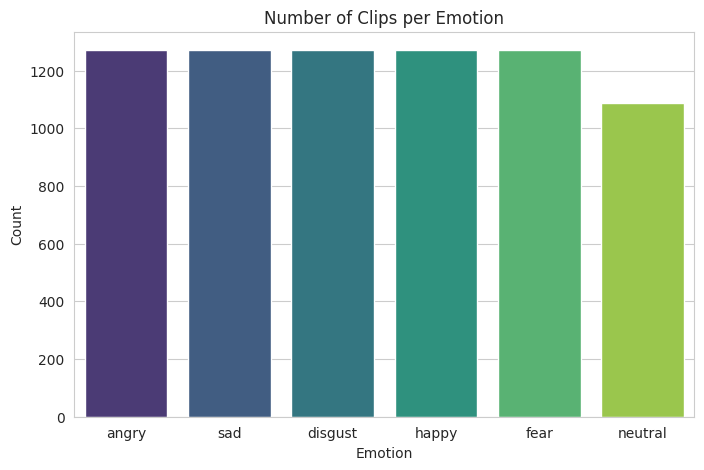

In [7]:

# --- Emotion class distribution ---
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="emotion", order=df["emotion"].value_counts().index, palette="viridis")
plt.title("Number of Clips per Emotion")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()


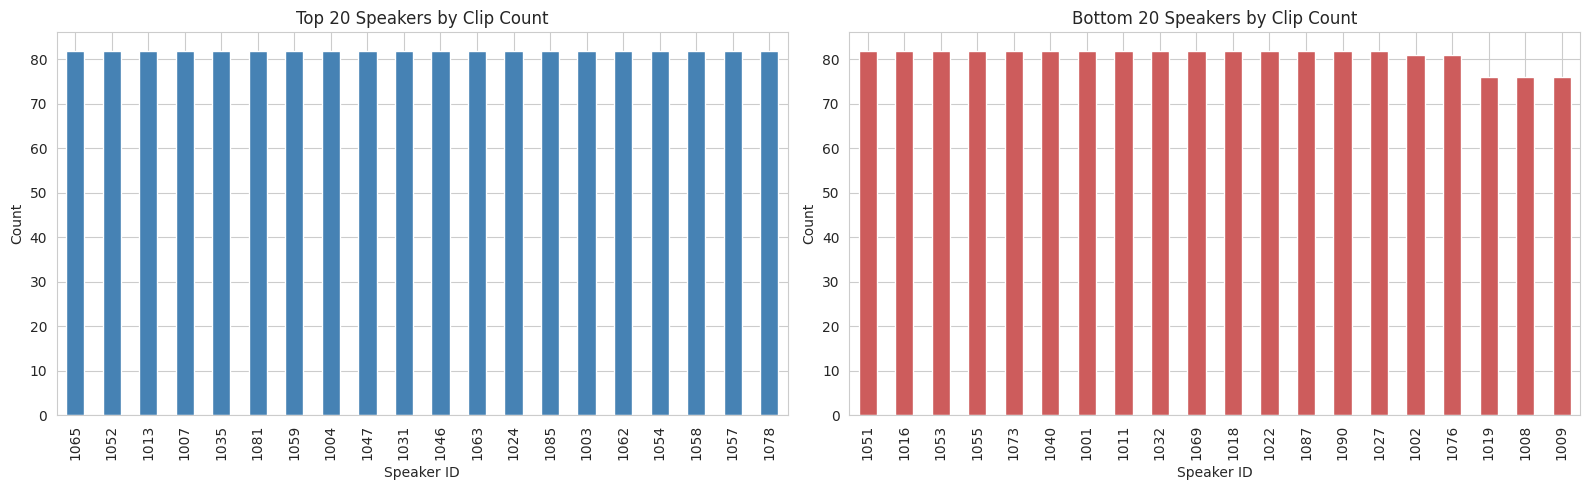

count    91.000000
mean     81.780220
std       1.083228
min      76.000000
25%      82.000000
50%      82.000000
75%      82.000000
max      82.000000
Name: count, dtype: float64


In [8]:

# --- Clips per speaker (top 20 + bottom 20) ---
speaker_counts = df['speaker_id'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
speaker_counts.head(20).plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Top 20 Speakers by Clip Count")
axes[0].set_xlabel("Speaker ID")
axes[0].set_ylabel("Count")

speaker_counts.tail(20).plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set_title("Bottom 20 Speakers by Clip Count")
axes[1].set_xlabel("Speaker ID")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.show()

print(speaker_counts.describe())


/tmp/ipykernel_1126/3136058167.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="intensity", order=df["intensity"].value_counts().index, palette="mako")


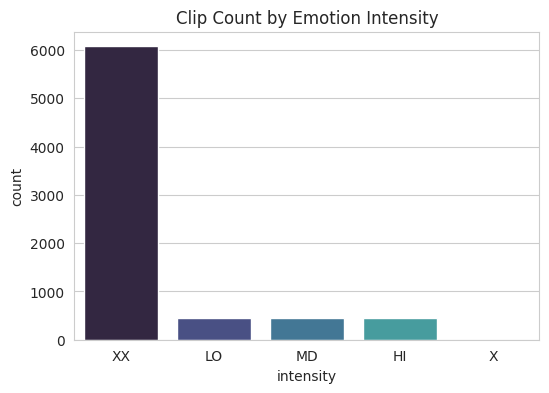

In [9]:

# --- Intensity distribution (bonus label available in CREMA-D) ---
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="intensity", order=df["intensity"].value_counts().index, palette="mako")
plt.title("Clip Count by Emotion Intensity")
plt.show()


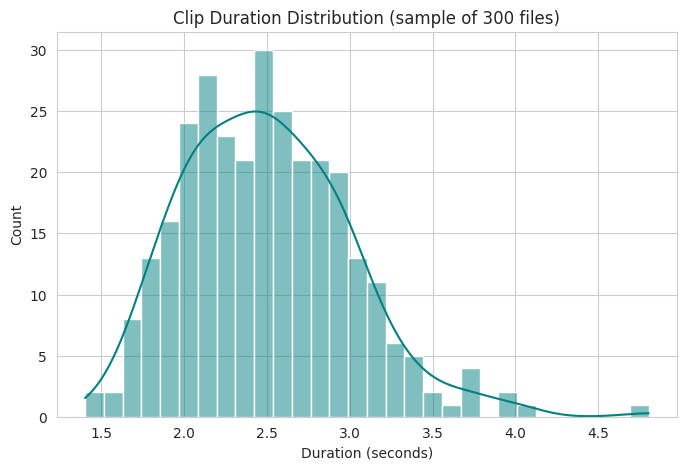

count    300.000000
mean       2.498715
std        0.506675
min        1.401375
25%        2.127109
50%        2.469125
75%        2.836187
max        4.804812
Name: duration, dtype: float64


In [10]:

# --- Audio duration distribution ---
def get_duration(path):
    try:
        return librosa.get_duration(path=path)
    except Exception:
        return np.nan

sample_for_duration = df.sample(min(300, len(df)), random_state=SEED)
sample_for_duration = sample_for_duration.copy()
sample_for_duration["duration"] = sample_for_duration["filepath"].apply(get_duration)

plt.figure(figsize=(8, 5))
sns.histplot(sample_for_duration["duration"].dropna(), bins=30, kde=True, color="teal")
plt.title("Clip Duration Distribution (sample of 300 files)")
plt.xlabel("Duration (seconds)")
plt.show()

print(sample_for_duration["duration"].describe())


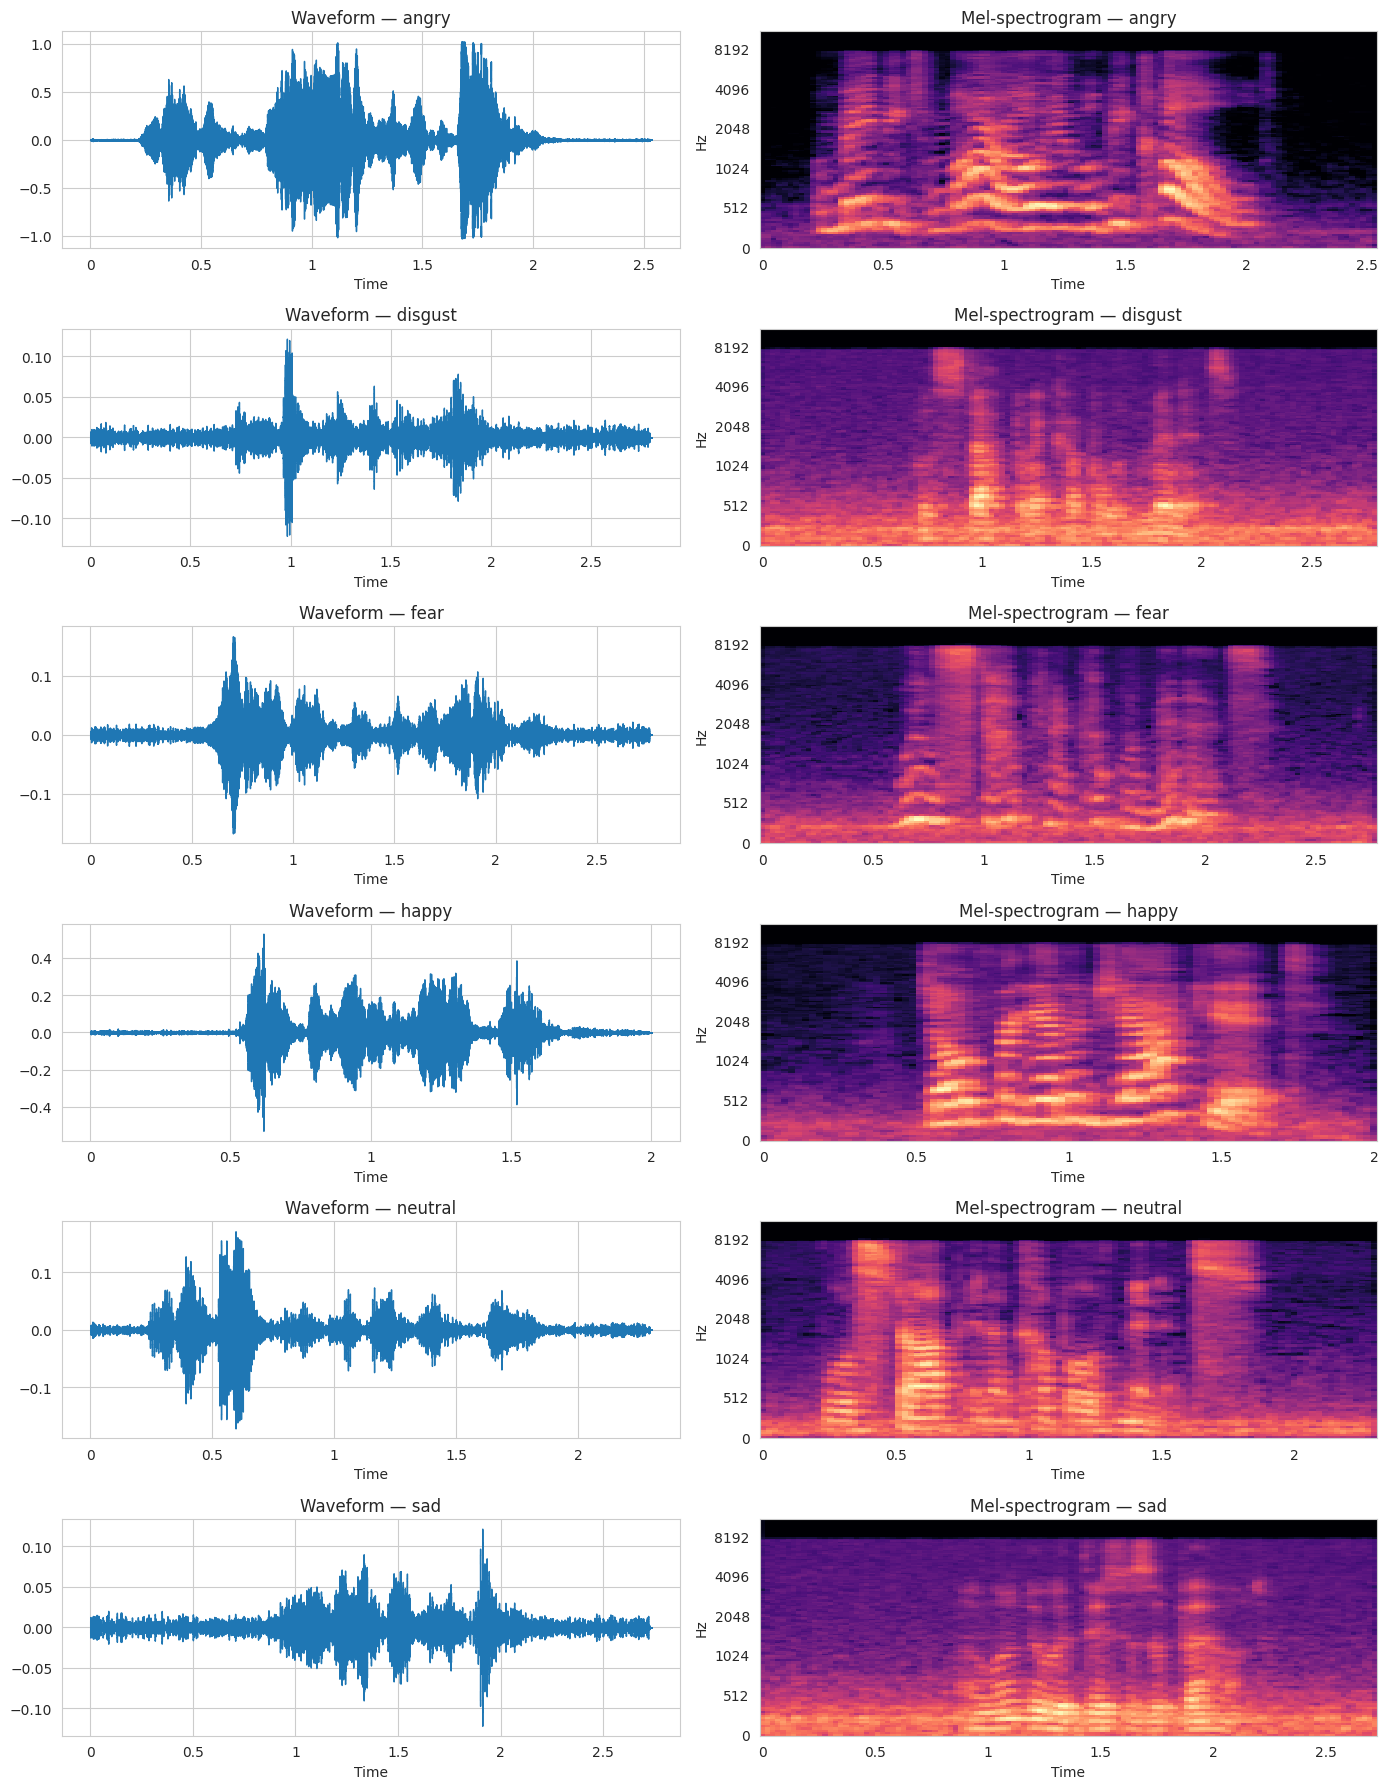

In [11]:

# --- Waveform + Mel-spectrogram examples, one per emotion ---
fig, axes = plt.subplots(len(EMOTION_MAP), 2, figsize=(14, 3 * len(EMOTION_MAP)))

for i, emotion in enumerate(sorted(df["emotion"].unique())):
    sample_path = df[df["emotion"] == emotion].sample(1, random_state=SEED)["filepath"].values[0]
    y, sr = librosa.load(sample_path, sr=SAMPLE_RATE)

    librosa.display.waveshow(y, sr=sr, ax=axes[i, 0])
    axes[i, 0].set_title(f"Waveform — {emotion}")

    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS)
    S_db = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="mel", ax=axes[i, 1])
    axes[i, 1].set_title(f"Mel-spectrogram — {emotion}")

plt.tight_layout()
plt.show()


## 4. Feature Extraction

Convert every clip into a fixed-size Mel-spectrogram: pad short clips /
truncate long ones so every sample has the same shape, which the CNN
requires.


In [12]:

def extract_melspectrogram(path, sr=SAMPLE_RATE, n_mels=N_MELS,
                            duration=DURATION, max_frames=MAX_FRAMES):
    y, _ = librosa.load(path, sr=sr, duration=duration)

    # pad/truncate raw audio to a fixed length first
    target_len = int(sr * duration)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]

    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    S_db = librosa.power_to_db(S, ref=np.max)

    # pad/truncate time axis to a fixed width
    if S_db.shape[1] < max_frames:
        pad_width = max_frames - S_db.shape[1]
        S_db = np.pad(S_db, ((0, 0), (0, pad_width)), mode="constant")
    else:
        S_db = S_db[:, :max_frames]

    # normalize to [0, 1]
    S_db = (S_db - S_db.min()) / (S_db.max() - S_db.min() + 1e-8)
    return S_db.astype(np.float32)

# quick sanity check on one file
test_spec = extract_melspectrogram(df["filepath"].iloc[0])
print("Spectrogram shape:", test_spec.shape)


Spectrogram shape: (128, 130)


In [13]:

from tqdm import tqdm

X = []
speaker_labels = []
emotion_labels = []

for _, row in tqdm(df.iterrows(), total=len(df)):
    try:
        spec = extract_melspectrogram(row["filepath"])
        X.append(spec)
        speaker_labels.append(row["speaker_id"])
        emotion_labels.append(row["emotion"])
    except Exception as e:
        print(f"Skipping {row['filepath']}: {e}")

X = np.array(X)
X = X[..., np.newaxis]  # add channel dimension for Conv2D
print("X shape:", X.shape)


100%|██████████| 7442/7442 [01:34<00:00, 79.02it/s]


X shape: (7442, 128, 130, 1)


In [14]:

speaker_encoder = LabelEncoder()
emotion_encoder = LabelEncoder()

y_speaker = speaker_encoder.fit_transform(speaker_labels)
y_emotion = emotion_encoder.fit_transform(emotion_labels)

num_speakers = len(speaker_encoder.classes_)
num_emotions = len(emotion_encoder.classes_)

print(f"num_speakers = {num_speakers}, num_emotions = {num_emotions}")


num_speakers = 91, num_emotions = 6


## 5. Train / Validation / Test Split\n\nStratify by emotion so every split has a balanced emotion mix; speakers are shared across splits since this is closed-set speaker identification (every speaker must appear in training).

In [15]:

X_train, X_temp, ys_train, ys_temp, ye_train, ye_temp = train_test_split(
    X, y_speaker, y_emotion, test_size=0.3, stratify=y_emotion, random_state=SEED
)
X_val, X_test, ys_val, ys_test, ye_val, ye_test = train_test_split(
    X_temp, ys_temp, ye_temp, test_size=0.5, stratify=ye_temp, random_state=SEED
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)


Train: (5209, 128, 130, 1) Val: (1116, 128, 130, 1) Test: (1117, 128, 130, 1)


## 6. Baseline Single-Task Models

Train two separate CNNs — one for speaker identification only, one for
emotion classification only. These are the reference point for judging
whether the multi-task model helps or hurts.


In [16]:

input_shape = X_train.shape[1:]

def build_cnn_backbone(input_shape):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu", name="shared_embedding")(x)
    x = layers.Dropout(0.4)(x)
    return inp, x


In [17]:

# ----- Baseline 1: Speaker-only CNN -----
inp_s, feat_s = build_cnn_backbone(input_shape)
out_s = layers.Dense(num_speakers, activation="softmax", name="speaker_out")(feat_s)
speaker_baseline = models.Model(inp_s, out_s, name="speaker_baseline")

speaker_baseline.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
speaker_baseline.summary()


Model: "speaker_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 130, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 130, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 130, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 65, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 65, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ shared_embedding (Dense)        │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ speaker_out (Dense)             │ (None, 91)             │        11,739 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,819 (475.86 KB)

 Trainable params: 121,371 (474.11 KB)

 Non-trainable params: 448 (1.75 KB)

In [18]:

early_stop = callbacks.EarlyStopping(patience=6, restore_best_weights=True)

hist_speaker_baseline = speaker_baseline.fit(
    X_train, ys_train,
    validation_data=(X_val, ys_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
)


Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 18s 61ms/step - accuracy: 0.0248 - loss: 4.4684 - val_accuracy: 0.0116 - val_loss: 5.2834
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.0407 - loss: 4.2506 - val_accuracy: 0.0090 - val_loss: 9.1821
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.0614 - loss: 3.9527 - val_accuracy: 0.0134 - val_loss: 9.0656
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.0883 - loss: 3.6841 - val_accuracy: 0.0116 - val_loss: 7.1860
Epoch 5/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.1238 - loss: 3.3561 - val_accuracy: 0.0878 - val_loss: 3.6888
Epoch 6/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.1714 - loss: 3.0817 - val_accuracy: 0.1048 - val_loss: 3.5863
Epoch 7/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.2079 - loss: 2.8334 - val_accuracy: 0.0986 - val_loss: 3.9768
Epoch 8/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.2720 - loss: 2.5188 - val_acc

In [19]:

# ----- Baseline 2: Emotion-only CNN -----
inp_e, feat_e = build_cnn_backbone(input_shape)
out_e = layers.Dense(num_emotions, activation="softmax", name="emotion_out")(feat_e)
emotion_baseline = models.Model(inp_e, out_e, name="emotion_baseline")

emotion_baseline.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

hist_emotion_baseline = emotion_baseline.fit(
    X_train, ye_train,
    validation_data=(X_val, ye_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
)


Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.3697 - loss: 1.5338 - val_accuracy: 0.1989 - val_loss: 2.8934
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.4200 - loss: 1.4381 - val_accuracy: 0.1694 - val_loss: 5.3992
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.4383 - loss: 1.3880 - val_accuracy: 0.2007 - val_loss: 3.8047
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.4634 - loss: 1.3528 - val_accuracy: 0.2930 - val_loss: 1.8124
Epoch 5/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.4792 - loss: 1.3116 - val_accuracy: 0.3629 - val_loss: 1.8992
Epoch 6/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.5018 - loss: 1.2786 - val_accuracy: 0.4579 - val_loss: 1.3619
Epoch 7/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.5151 - loss: 1.2447 - val_accuracy: 0.1837 - val_loss: 2.5253
Epoch 8/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.5316 - loss: 1.2171 - val_acc

## 7. Multi-Task Model (Shared Backbone, Dual Heads)

In [20]:

inp_mt, feat_mt = build_cnn_backbone(input_shape)

speaker_head = layers.Dense(num_speakers, activation="softmax", name="speaker_out")(feat_mt)
emotion_head = layers.Dense(num_emotions, activation="softmax", name="emotion_out")(feat_mt)

multitask_model = models.Model(inp_mt, [speaker_head, emotion_head], name="multitask_model")

# loss weighting: start equal, tune later based on which task lags
LOSS_WEIGHTS = {"speaker_out": 0.5, "emotion_out": 0.5}

multitask_model.compile(
    optimizer="adam",
    loss={
        "speaker_out": "sparse_categorical_crossentropy",
        "emotion_out": "sparse_categorical_crossentropy",
    },
    loss_weights=LOSS_WEIGHTS,
    metrics={"speaker_out": "accuracy", "emotion_out": "accuracy"},
)
multitask_model.summary()


Model: "multitask_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 130,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 128, 130,  │        320 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 130,  │        128 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 64, 65,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 64, 65,    │     18,496 │ max_pooling2d_6[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 65,    │        256 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_7[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ max_pooling2d_8[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_embedding    │ (None, 128)       │     16,512 │ global_average_p… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ shared_embedding… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ speaker_out (Dense) │ (None, 91)        │     11,739 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emotion_out (Dense) │ (None, 6)         │        774 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 122,593 (478.88 KB)

 Trainable params: 122,145 (477.13 KB)

 Non-trainable params: 448 (1.75 KB)

In [21]:

hist_multitask = multitask_model.fit(
    X_train, {"speaker_out": ys_train, "emotion_out": ye_train},
    validation_data=(X_val, {"speaker_out": ys_val, "emotion_out": ye_val}),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
)


Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 15s 53ms/step - emotion_out_accuracy: 0.3719 - emotion_out_loss: 1.5354 - loss: 3.0064 - speaker_out_accuracy: 0.0200 - speaker_out_loss: 4.4771 - val_emotion_out_accuracy: 0.1703 - val_emotion_out_loss: 3.7330 - val_loss: 4.4167 - val_speaker_out_accuracy: 0.0134 - val_speaker_out_loss: 5.1020
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - emotion_out_accuracy: 0.4033 - emotion_out_loss: 1.4592 - loss: 2.9011 - speaker_out_accuracy: 0.0303 - speaker_out_loss: 4.3430 - val_emotion_out_accuracy: 0.1703 - val_emotion_out_loss: 6.6691 - val_loss: 6.7942 - val_speaker_out_accuracy: 0.0116 - val_speaker_out_loss: 6.9209
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - emotion_out_accuracy: 0.4227 - emotion_out_loss: 1.4235 - loss: 2.8229 - speaker_out_accuracy: 0.0457 - speaker_out_loss: 4.2222 - val_emotion_out_accuracy: 0.1694 - val_emotion_out_loss: 5.8190 - val_loss: 6.4461 - val_speaker_out_accuracy: 0.0143 - val_speaker_out_loss: 7

## 8. Training Curves

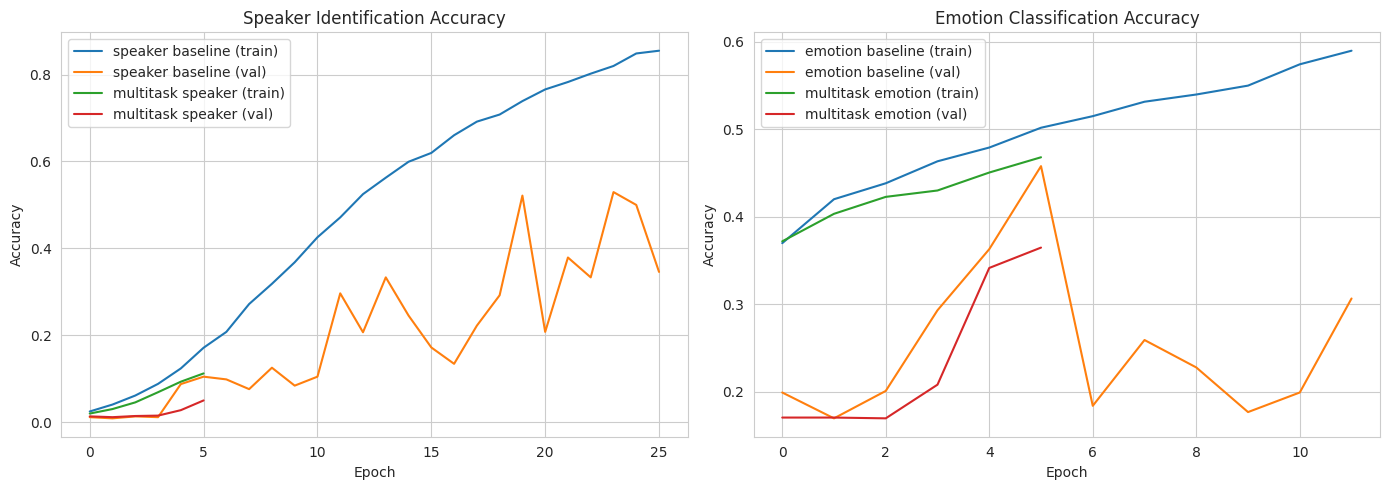

In [22]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hist_speaker_baseline.history["accuracy"], label="speaker baseline (train)")
axes[0].plot(hist_speaker_baseline.history["val_accuracy"], label="speaker baseline (val)")
axes[0].plot(hist_multitask.history["speaker_out_accuracy"], label="multitask speaker (train)")
axes[0].plot(hist_multitask.history["val_speaker_out_accuracy"], label="multitask speaker (val)")
axes[0].set_title("Speaker Identification Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(hist_emotion_baseline.history["accuracy"], label="emotion baseline (train)")
axes[1].plot(hist_emotion_baseline.history["val_accuracy"], label="emotion baseline (val)")
axes[1].plot(hist_multitask.history["emotion_out_accuracy"], label="multitask emotion (train)")
axes[1].plot(hist_multitask.history["val_emotion_out_accuracy"], label="multitask emotion (val)")
axes[1].set_title("Emotion Classification Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


## 9. Evaluation on Test Set

In [23]:

# ----- Baseline evaluation -----
speaker_baseline_test_loss, speaker_baseline_test_acc = speaker_baseline.evaluate(X_test, ys_test, verbose=0)
emotion_baseline_test_loss, emotion_baseline_test_acc = emotion_baseline.evaluate(X_test, ye_test, verbose=0)

print(f"Baseline speaker test accuracy: {speaker_baseline_test_acc:.4f}")
print(f"Baseline emotion test accuracy: {emotion_baseline_test_acc:.4f}")


Baseline speaker test accuracy: 0.4897
Baseline emotion test accuracy: 0.4745


In [24]:

# ----- Multi-task evaluation -----
mt_eval = multitask_model.evaluate(
    X_test, {"speaker_out": ys_test, "emotion_out": ye_test}, verbose=0, return_dict=True
)
mt_speaker_test_acc = mt_eval["speaker_out_accuracy"]
mt_emotion_test_acc = mt_eval["emotion_out_accuracy"]

print(f"Multi-task speaker test accuracy: {mt_speaker_test_acc:.4f}")
print(f"Multi-task emotion test accuracy: {mt_emotion_test_acc:.4f}")


Multi-task speaker test accuracy: 0.0125
Multi-task emotion test accuracy: 0.1710


35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


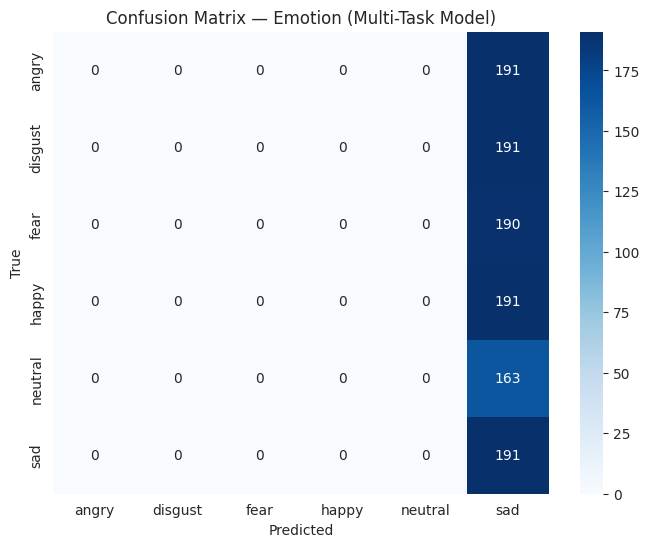

              precision    recall  f1-score   support

       angry       0.00      0.00      0.00       191
     disgust       0.00      0.00      0.00       191
        fear       0.00      0.00      0.00       190
       happy       0.00      0.00      0.00       191
     neutral       0.00      0.00      0.00       163
         sad       0.17      1.00      0.29       191

    accuracy                           0.17      1117
   macro avg       0.03      0.17      0.05      1117
weighted avg       0.03      0.17      0.05      1117



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [25]:

# ----- Confusion matrix: emotion (multi-task model) -----
_, ye_pred_probs = multitask_model.predict(X_test)
ye_pred = np.argmax(ye_pred_probs, axis=1)

cm = confusion_matrix(ye_test, ye_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=emotion_encoder.classes_,
            yticklabels=emotion_encoder.classes_)
plt.title("Confusion Matrix — Emotion (Multi-Task Model)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print(classification_report(ye_test, ye_pred, target_names=emotion_encoder.classes_))


35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


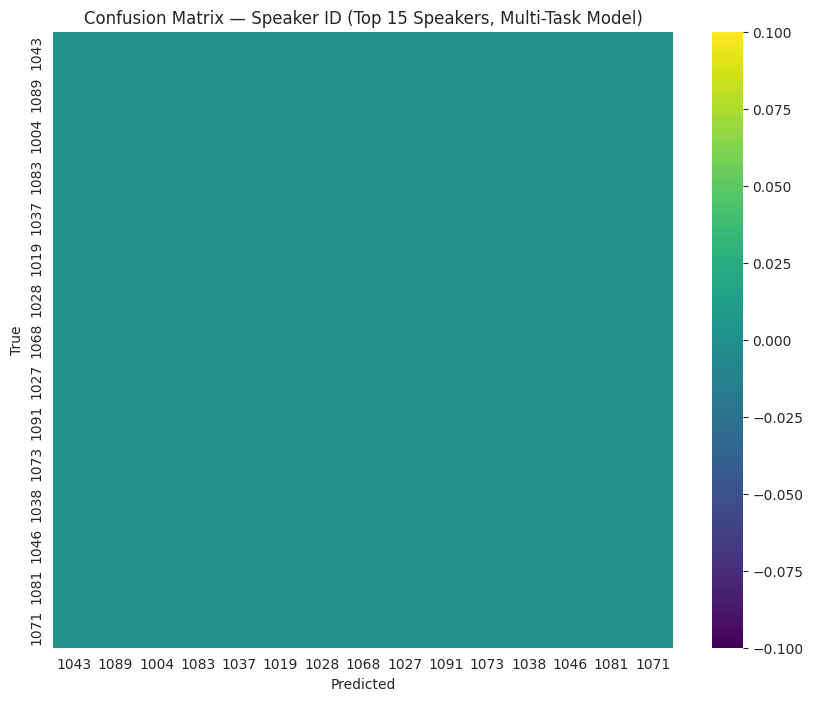

In [26]:

# ----- Confusion matrix: speaker (multi-task model), top 15 most frequent speakers only for readability -----
ys_pred_probs, _ = multitask_model.predict(X_test)
ys_pred = np.argmax(ys_pred_probs, axis=1)

top_speakers = pd.Series(ys_test).value_counts().head(15).index
mask = np.isin(ys_test, top_speakers)

cm_speaker = confusion_matrix(ys_test[mask], ys_pred[mask], labels=top_speakers)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_speaker, annot=False, cmap="viridis",
            xticklabels=speaker_encoder.classes_[top_speakers],
            yticklabels=speaker_encoder.classes_[top_speakers])
plt.title("Confusion Matrix — Speaker ID (Top 15 Speakers, Multi-Task Model)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


## 10. Multi-Task vs. Single-Task Comparison

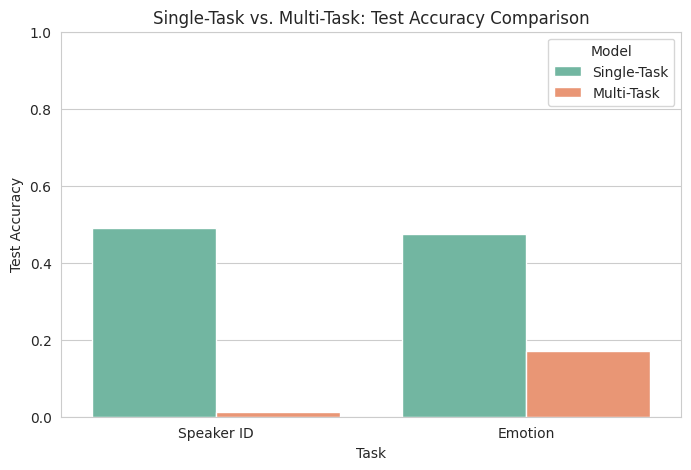

,Task,Model,Test Accuracy
0,Speaker ID,Single-Task,0.489705
1,Speaker ID,Multi-Task,0.012534
2,Emotion,Single-Task,0.474485
3,Emotion,Multi-Task,0.170994


In [27]:

comparison_df = pd.DataFrame({
    "Task": ["Speaker ID", "Speaker ID", "Emotion", "Emotion"],
    "Model": ["Single-Task", "Multi-Task", "Single-Task", "Multi-Task"],
    "Test Accuracy": [
        speaker_baseline_test_acc, mt_speaker_test_acc,
        emotion_baseline_test_acc, mt_emotion_test_acc,
    ],
})

plt.figure(figsize=(8, 5))
sns.barplot(data=comparison_df, x="Task", y="Test Accuracy", hue="Model", palette="Set2")
plt.title("Single-Task vs. Multi-Task: Test Accuracy Comparison")
plt.ylim(0, 1)
plt.show()

comparison_df


**Interpretation guide** (fill in once you have real numbers):
- If multi-task accuracy is *higher* than single-task on a given task → positive transfer, the shared features helped.
- If multi-task accuracy is *lower* → negative transfer, the two tasks pulled the shared representation in conflicting directions. Try re-tuning `LOSS_WEIGHTS` toward the harder task.


## 11. Embedding Visualization (t-SNE)

Visualize the shared 128-dim embedding layer (`shared_embedding`) from the
multi-task model, colored once by speaker and once by emotion, to see how
well the shared representation separates each task.


In [28]:

embedding_model = models.Model(
    inputs=multitask_model.input,
    outputs=multitask_model.get_layer("shared_embedding").output,
)

# use a manageable subsample for t-SNE (it's slow on large sets)
sample_idx = np.random.choice(len(X_test), size=min(500, len(X_test)), replace=False)
embeddings = embedding_model.predict(X_test[sample_idx])

tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
emb_2d = tsne.fit_transform(embeddings)


16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step


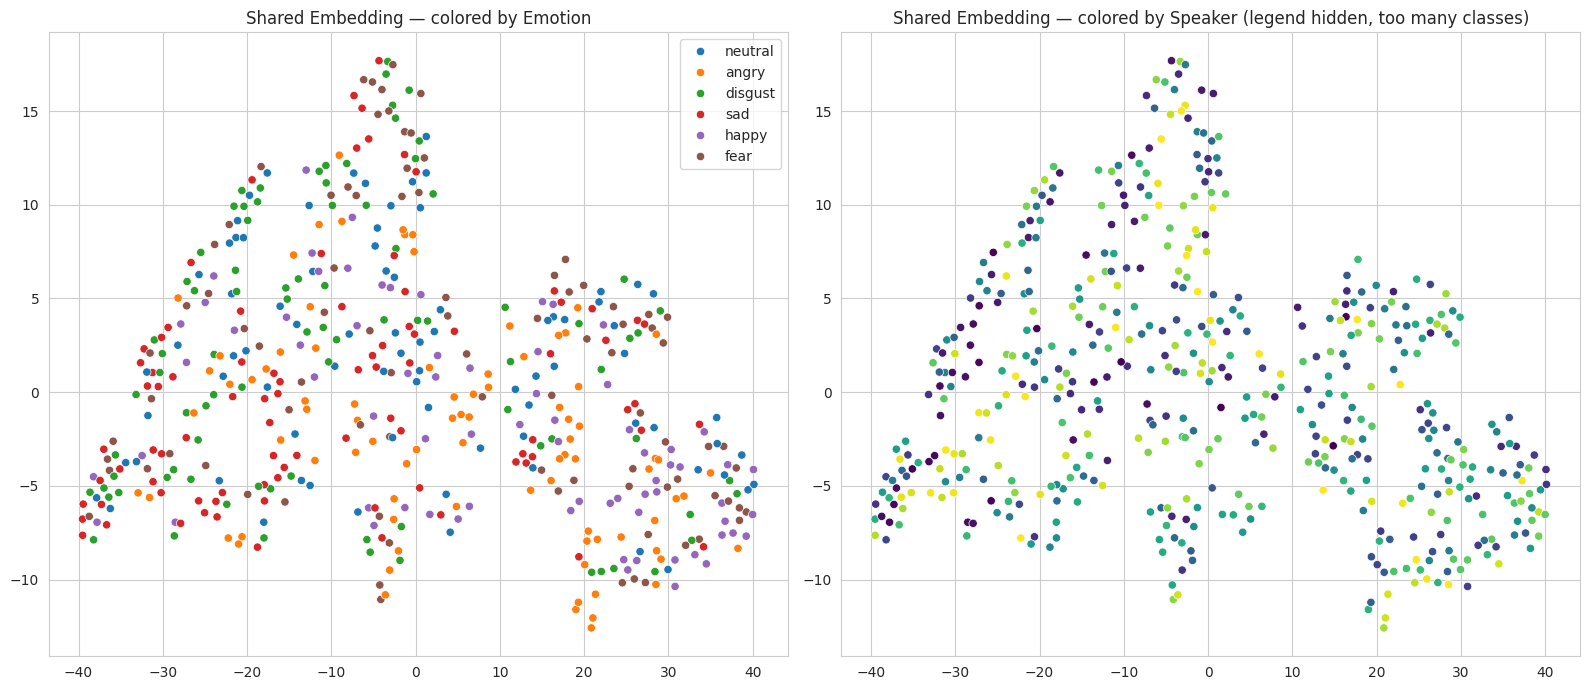

In [29]:

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

emotion_sample = emotion_encoder.inverse_transform(ye_test[sample_idx])
sns.scatterplot(x=emb_2d[:, 0], y=emb_2d[:, 1], hue=emotion_sample, palette="tab10", ax=axes[0], legend="full")
axes[0].set_title("Shared Embedding — colored by Emotion")

speaker_sample = ys_test[sample_idx]
sns.scatterplot(x=emb_2d[:, 0], y=emb_2d[:, 1], hue=speaker_sample, palette="viridis", ax=axes[1], legend=False)
axes[1].set_title("Shared Embedding — colored by Speaker (legend hidden, too many classes)")

plt.tight_layout()
plt.show()


## 12. Conclusion

Fill in after running:

- **Speaker ID accuracy:** single-task = `___`, multi-task = `___`
- **Emotion accuracy:** single-task = `___`, multi-task = `___`
- **Transfer observed:** (positive / negative / mixed) — explain briefly why, referencing the t-SNE plot and confusion matrices.
- **Limitation:** this is closed-set speaker identification — the model only recognizes the ~91 actors it was trained on. It cannot identify a new, unseen speaker.
- **Real-world applicability:** fixed-membership scenarios (smart home with known household members, internal call-center QA with a known agent roster) — not open-world speaker recognition.
- **Future extension:** replace the speaker softmax head with an embedding + similarity-based approach (e.g., triplet loss) to support open-set speaker verification for unseen speakers.
